<a href="https://colab.research.google.com/github/ivonneurquiza78-coder/i310D/blob/main/telco_churn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn – Full Analysis
**I310D: Introduction to Human-Centered Data Science**


By: Ivonne Urquiza-Sanchez, Anya Patil, Shiroz Kazani, Haleema Shah

This notebook covers:
1. Setup & Installs
2. Load & Clean Data
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model Training (Logistic Regression, XGBoost)
6. Model Comparison
7. SHAP Interpretability
8. Fairness Analysis

## Cell 1 - Install & Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

## Cell 2 - Load & Clean Data

In [5]:
DATA_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nChurn distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isna().sum()
print(f'\nMissing TotalCharges: {n_missing} (filled with median)')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop(columns=['customerID'], inplace=True)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

df.head()

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Missing TotalCharges: 11 (filled with median)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Cell 3 - Exploratory Data Analysis (EDA)

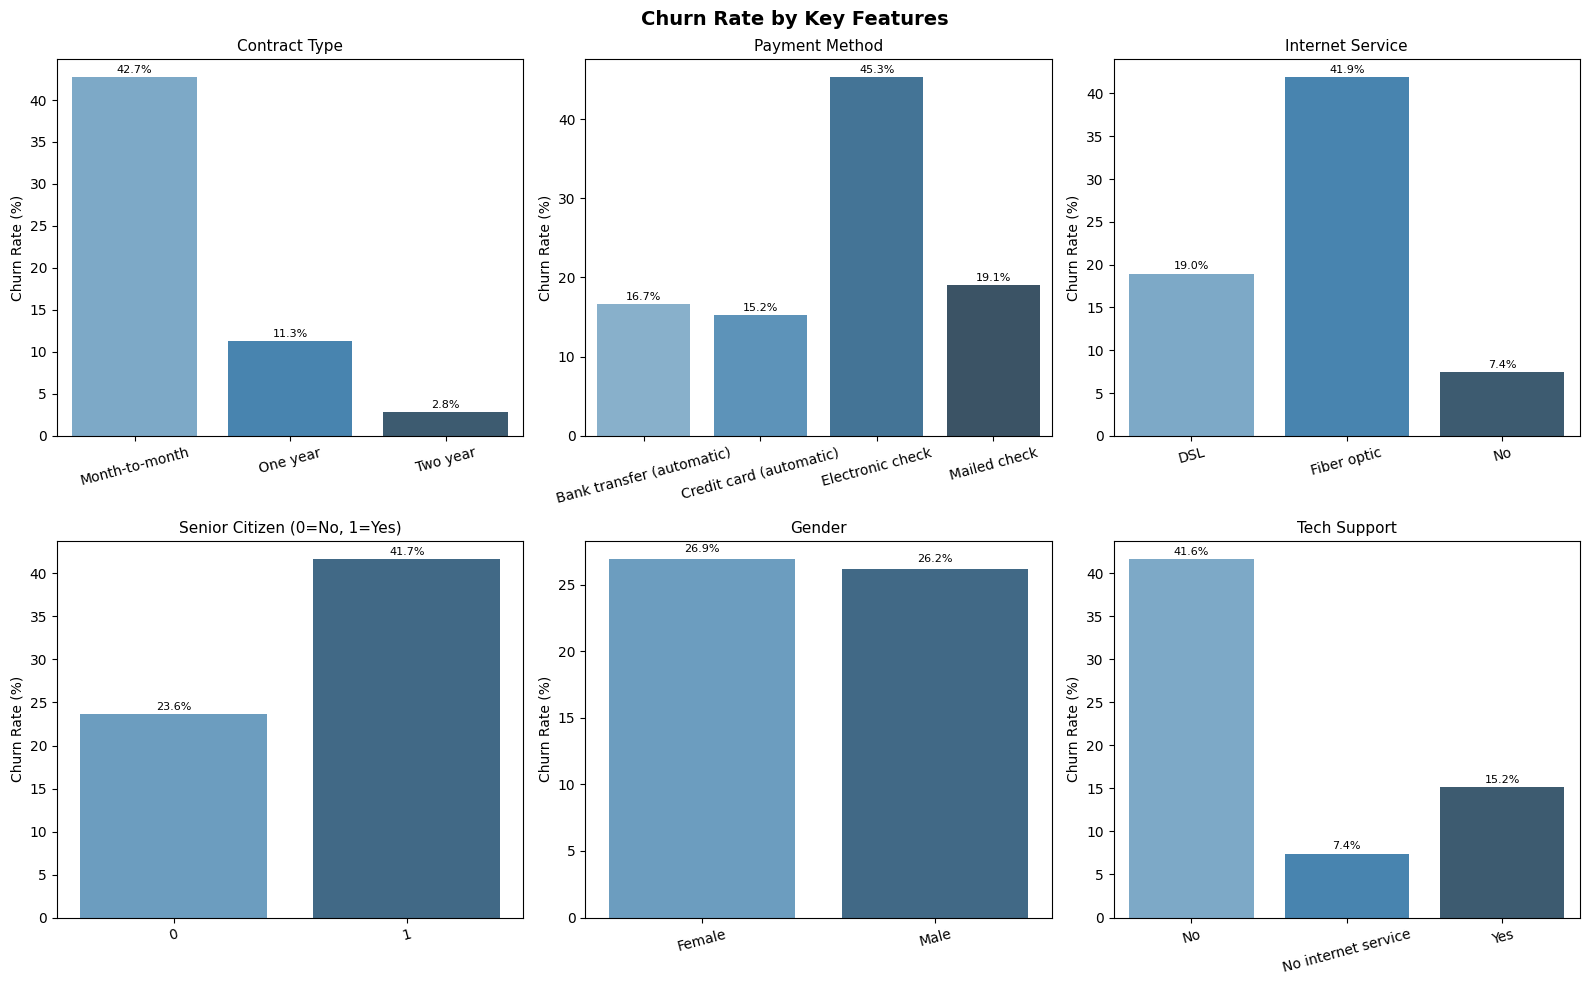

In [6]:
def churn_rate_bar(ax, col, title):
    ct = df.groupby(col)['Churn'].mean().reset_index()
    ct['Churn'] *= 100
    sns.barplot(data=ct, x=col, y='Churn', ax=ax, palette='Blues_d')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Churn Rate by Key Features', fontsize=14, fontweight='bold')

churn_rate_bar(axes[0,0], 'Contract',        'Contract Type')
churn_rate_bar(axes[0,1], 'PaymentMethod',   'Payment Method')
churn_rate_bar(axes[0,2], 'InternetService', 'Internet Service')
churn_rate_bar(axes[1,0], 'SeniorCitizen',   'Senior Citizen (0=No, 1=Yes)')
churn_rate_bar(axes[1,1], 'gender',          'Gender')
churn_rate_bar(axes[1,2], 'TechSupport',     'Tech Support')

plt.tight_layout()
plt.show()

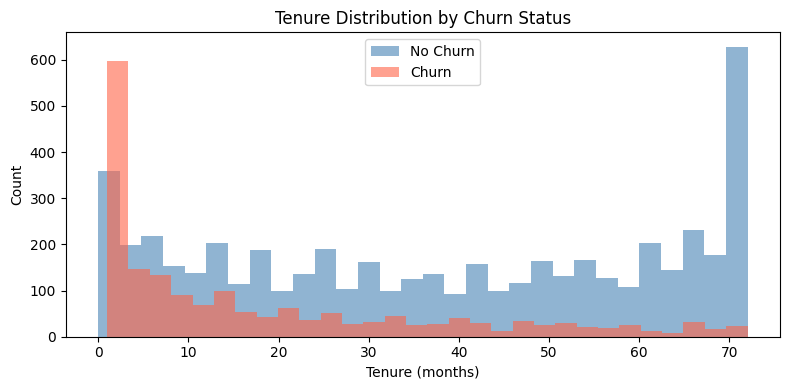

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Churn']==0]['tenure'].plot(kind='hist', bins=30, alpha=0.6, label='No Churn', ax=ax, color='steelblue')
df[df['Churn']==1]['tenure'].plot(kind='hist', bins=30, alpha=0.6, label='Churn',    ax=ax, color='tomato')
ax.set_title('Tenure Distribution by Churn Status')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

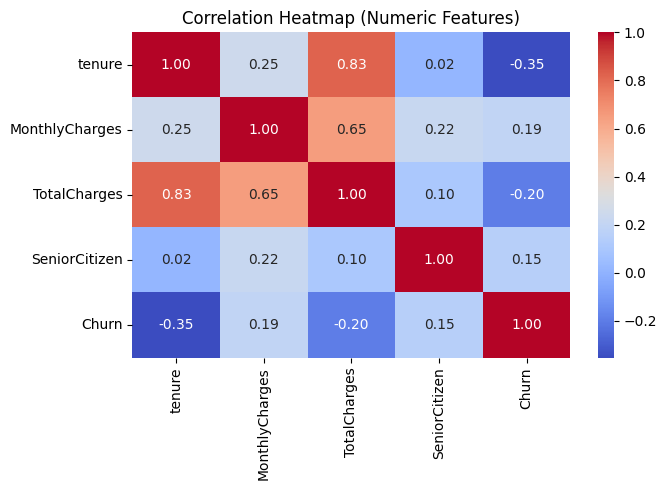

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
numeric_cols_heat = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
sns.heatmap(df[numeric_cols_heat].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

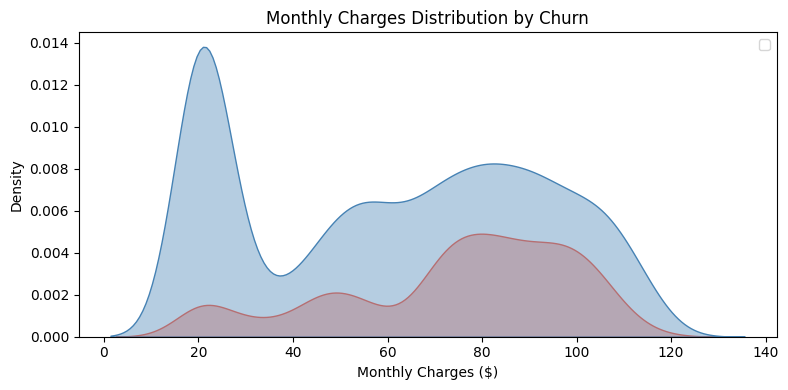

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, alpha=0.4, ax=ax,
            palette={0: 'steelblue', 1: 'tomato'})
ax.set_title('Monthly Charges Distribution by Churn')
ax.set_xlabel('Monthly Charges ($)')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

## Cell 4 - Preprocessing & Train/Test Split

In [10]:
TARGET = 'Churn'
RANDOM_STATE = 42
X = df.drop(columns=[TARGET])
y = df[TARGET]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols     = X.select_dtypes(include=np.number).columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numeric features     ({len(numeric_cols)}): {numeric_cols}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%')

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
])

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric features     (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Train: 5634 rows  |  Test: 1409 rows
Train churn rate: 26.5%  |  Test churn rate: 26.5%


## Cell 5a - Logistic Regression



In [11]:
results = {}  # stores results for all models

lr_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

results['Logistic Regression'] = {
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_prob_lr),
    'y_pred': y_pred_lr,
    'y_prob': y_prob_lr,
}
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Cell 5b - XGBoost

In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
    )),
])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_prob_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'f1': f1_score(y_test, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test, y_prob_xgb),
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb,
}
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.93      0.67      0.78      1035
       Churn       0.48      0.85      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.72      0.73      1409



## Cell 6 — Model Comparison

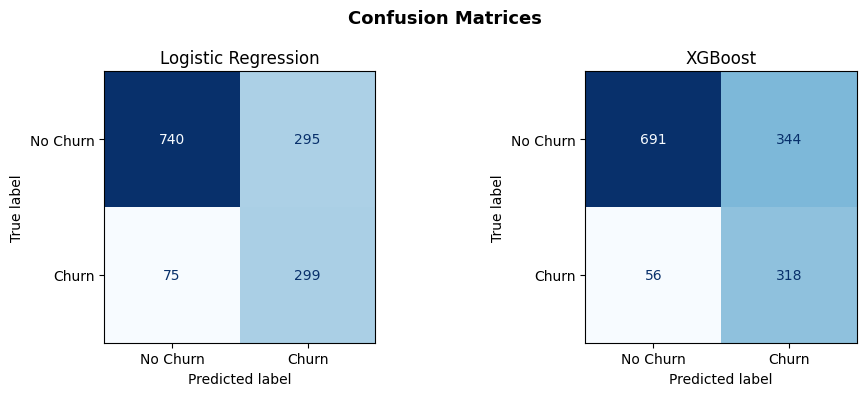

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 7 — SHAP Interpretability (XGBoost)

In [14]:
X_test_transformed = xgb_pipe.named_steps['preprocessor'].transform(X_test)
xgb_ohe_features   = xgb_pipe.named_steps['preprocessor'] \
    .named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
xgb_all_features = numeric_cols + xgb_ohe_features

explainer   = shap.TreeExplainer(xgb_pipe.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed)
print('SHAP values computed.')

SHAP values computed.


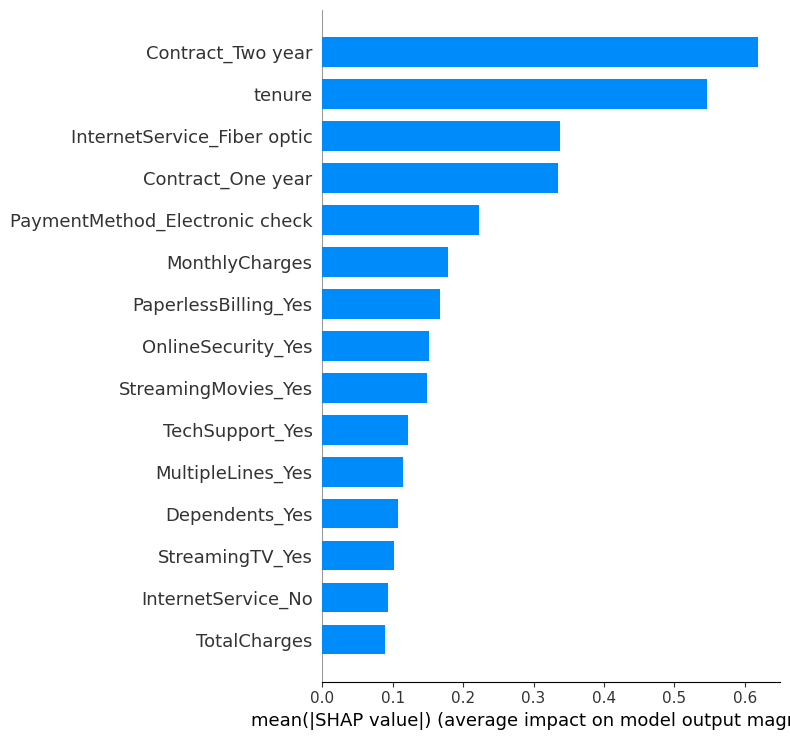

In [15]:
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=xgb_all_features,
    plot_type='bar',
    max_display=15,
    show=True
)

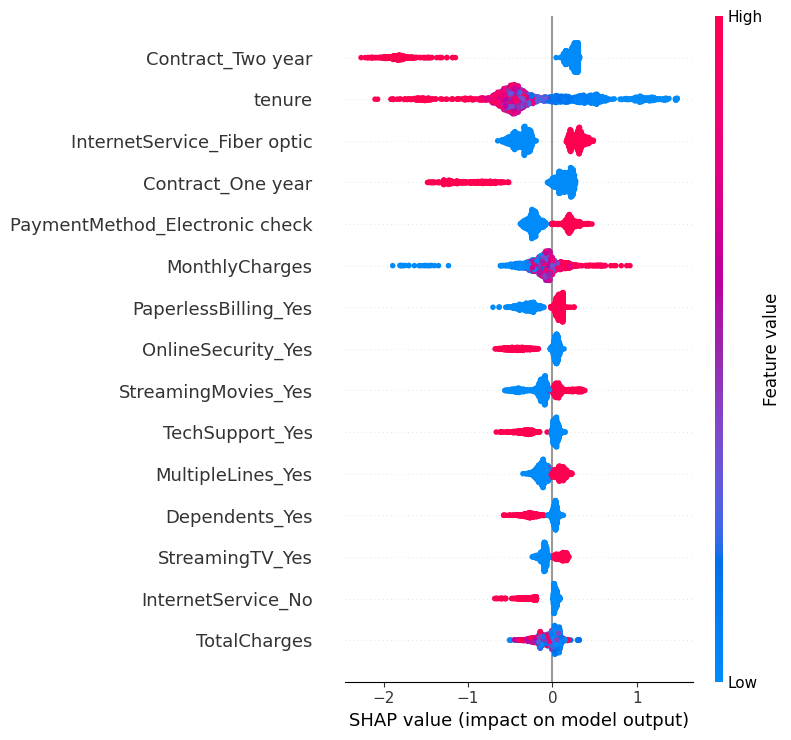

In [16]:
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=xgb_all_features,
    max_display=15,
    show=True
)

## Cell 8 — Fairness Analysis

In [17]:
def fairness_report(group_col, group_vals, label_map=None):
    """Compute F1 and recall for each subgroup."""
    rows = []
    for val in group_vals:
        mask = X_test[group_col] == val
        if mask.sum() < 10:
            continue
        gt   = y_test[mask]
        pred = y_pred_xgb[mask]
        display_val = label_map[val] if label_map else str(val)
        rows.append({
            'Group':         f'{group_col}={display_val}',
            'N':             int(mask.sum()),
            'Churn Rate':    f'{gt.mean()*100:.1f}%',
            'F1-Score':      round(f1_score(gt, pred, zero_division=0), 3),
            'Recall (Churn)':f'{(pred[gt==1]==1).mean()*100:.1f}%',
        })
    return pd.DataFrame(rows)

gender_df  = fairness_report('gender',        ['Female', 'Male'])
senior_df  = fairness_report('SeniorCitizen', [0, 1], {0: 'Non-Senior', 1: 'Senior'})
fairness_df = pd.concat([gender_df, senior_df], ignore_index=True)

display(fairness_df)

,Group,N,Churn Rate,F1-Score,Recall (Churn)
0,gender=Female,687,28.1%,0.625,83.9%
1,gender=Male,722,25.1%,0.602,86.2%
2,SeniorCitizen=Non-Senior,1187,23.3%,0.580,81.2%
3,SeniorCitizen=Senior,222,44.1%,0.715,95.9%
